# Create delta-DG1 model

**Goal:**

Create a model for the DG1 model that uses a delta subinterval plus the CG1 interval for the bottom branch.

**Procedure:**
1. Create a new `create_model` function for the delta model.
2. Save the updated config for the new delta model.
3. Decide on alpha, term: Proportion of the cell cycle length similar to Xin's alpha value. (What is the literature on the estimated length of G1?)
4. Create a new calcH function to create the new delta H model.
    - (Will calcH just work with the new intervals?)
5. Plot the model diagram (validation)
6. Plot the growth diagram (validation)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.create_models_delta import create_wt1_model, create_wt2_model

alpha = 22
modelfile1 = create_wt1_model(f'models/yl_cell_cycle/wt1_rg1_delta.{alpha}.label', alpha)

alpha = 20
modelfile2 = create_wt2_model(f'models/yl_cell_cycle/wt2_rg1_delta.{alpha}.label', alpha)


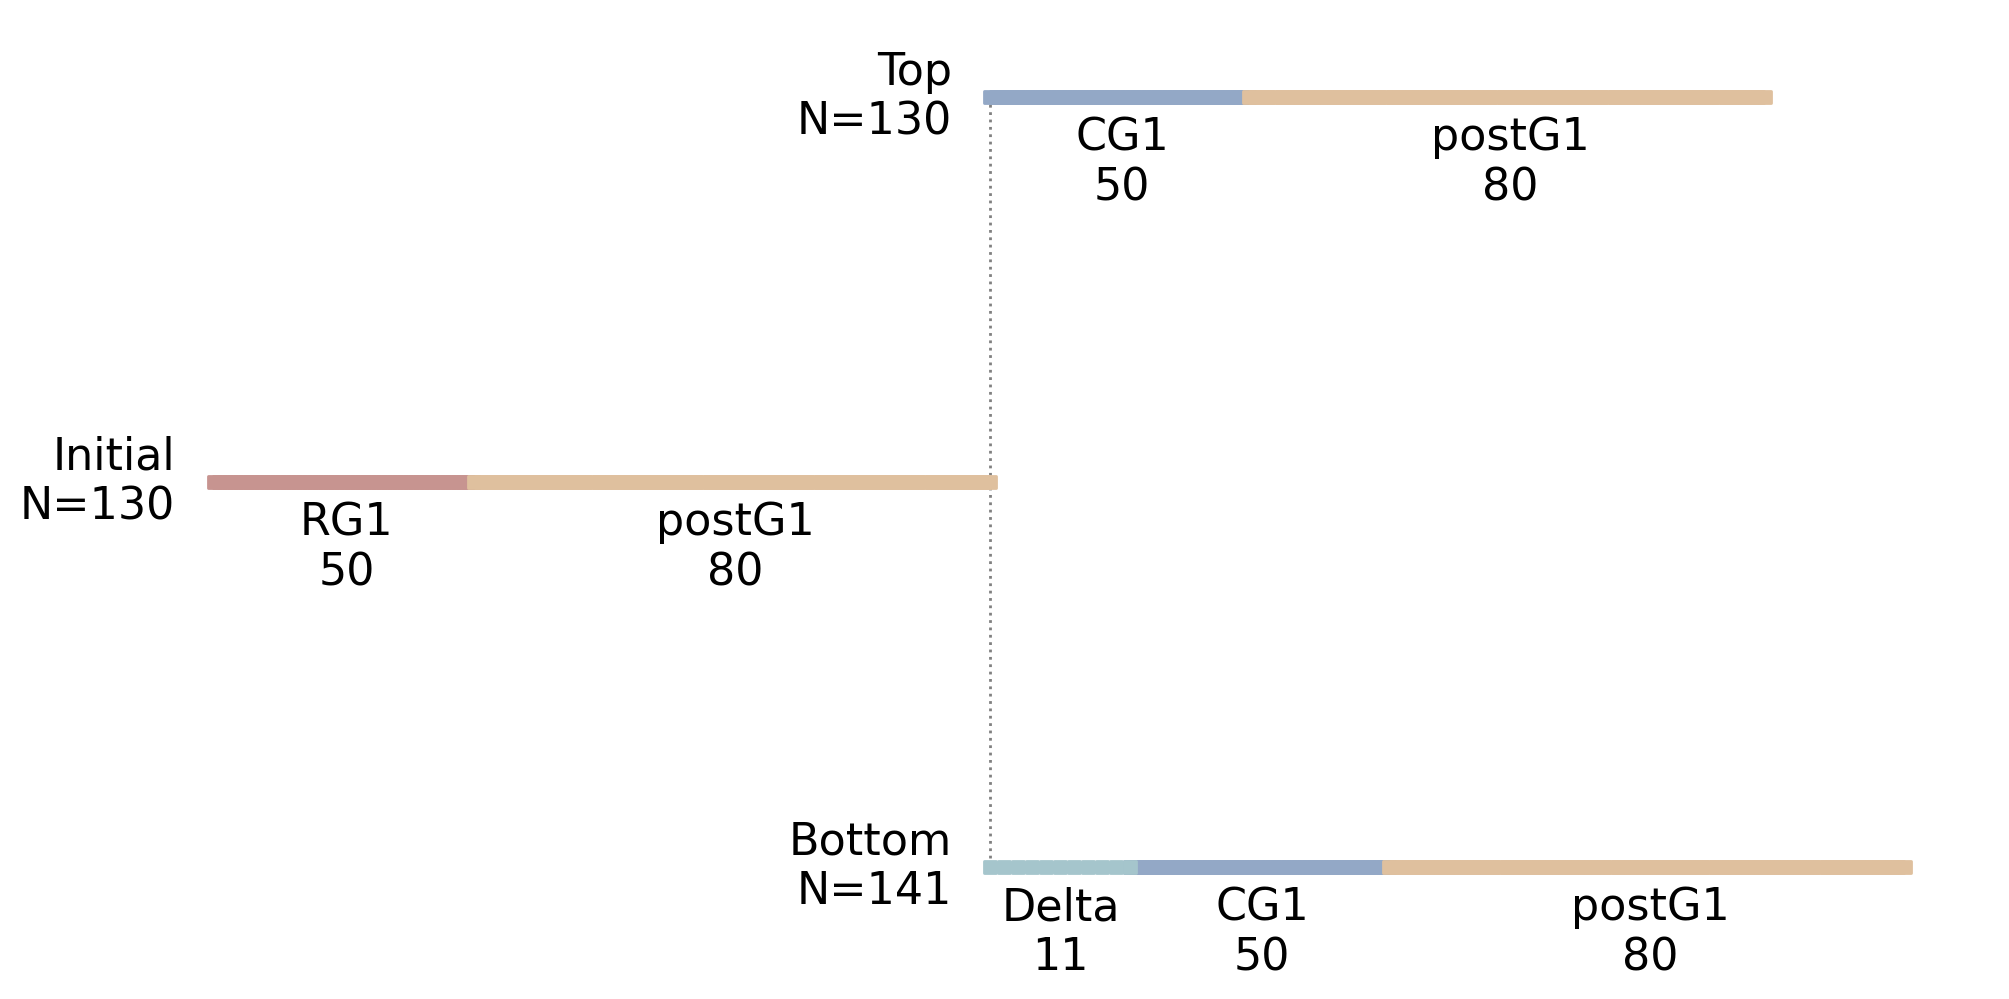

In [3]:
from src.ModelFile import ModelFile

model_file_loaded = ModelFile()
model_file_loaded.load_model(modelfile2)
model_file_loaded.plot_model()

In [16]:
# Create the H for the updated model config to include the H config
from src.delta_config import load_yl_delta_config
config1 = load_yl_delta_config(1)
config2 = load_yl_delta_config(2)

In [19]:
from src.helpers import calcH
H, Hpositions = calcH(config1.intervals_wt1, config1.WT1_TIMEPOINTS)

Text(0.5, 1.0, 'DG1 H matrix')

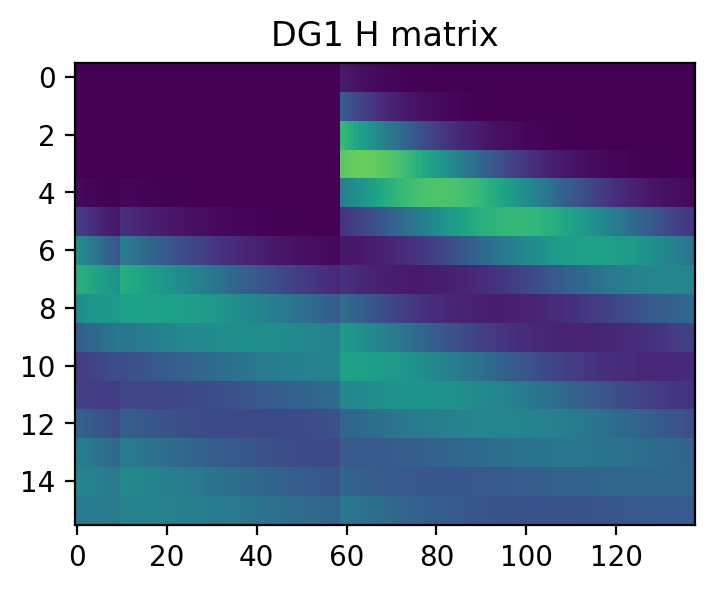

In [21]:
# Checking the DG1 is a smooth transition from the "Delta" phase 
# into CG1
plt.figure(figsize=(4, 3))
bottom_indices = config1.get_Hpositions_for_branch('b')
bottom_H = H[:, bottom_indices]
plt.imshow(bottom_H, vmax=0.02, aspect='auto')
plt.title("DG1 H matrix")

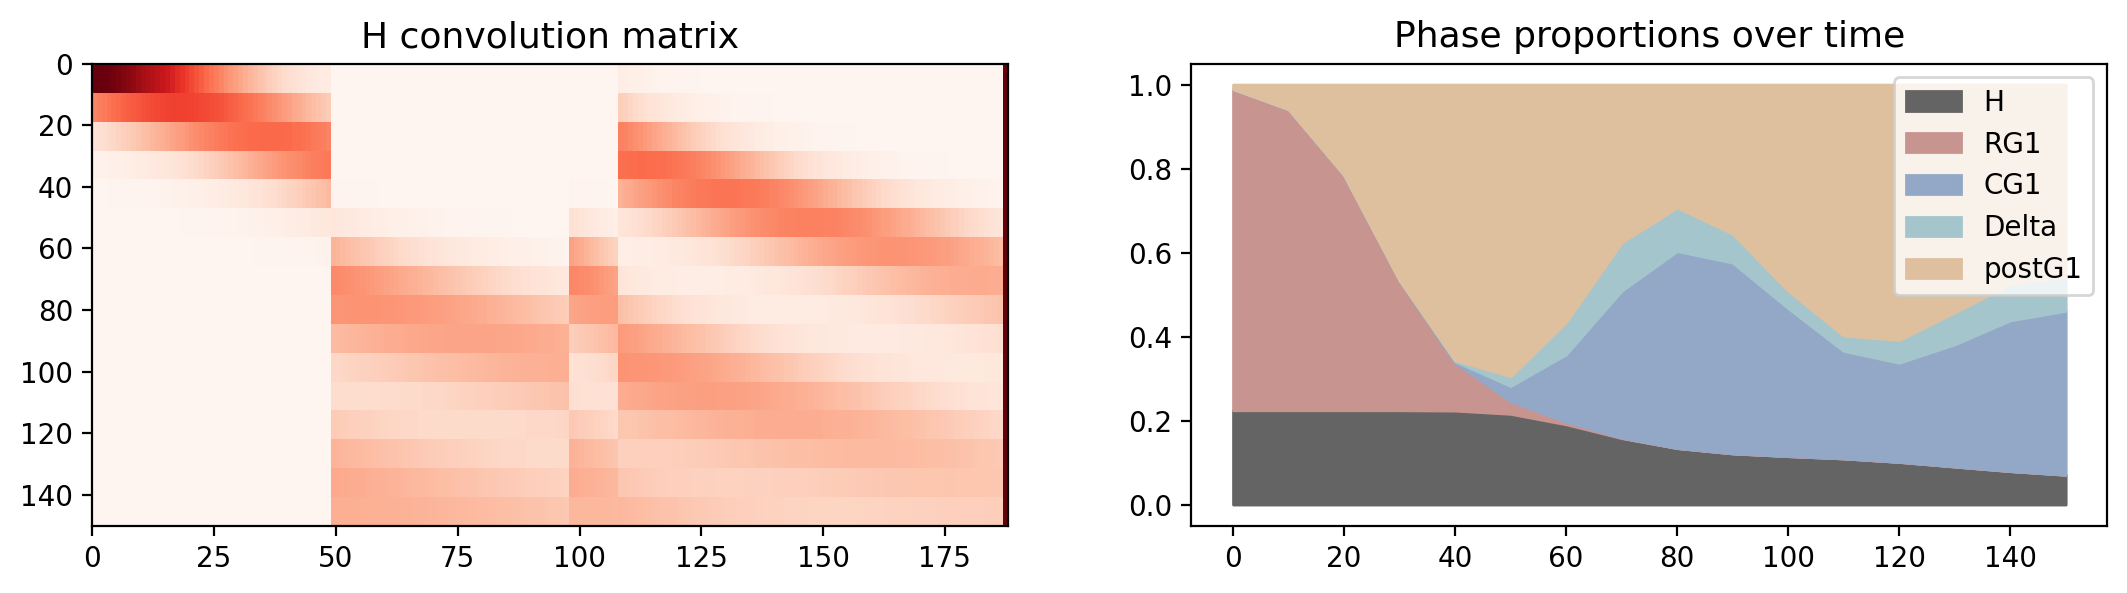

In [22]:
from src.config import plot_H
plot_H(config1, H)

In [23]:
# Next deconvolve the gene expression for CLB2, DSE1, DSE2, and CLN1
# I expect the DSE genes to be affected the most, will the CG1 and DG1 look similar?
# What will the delta region look like?

# Then deconvolve all of the genes
from src.model import Model

model = Model(config1, 'DSE3')

In [24]:
model.deconvolve_find_optimal_gamma()

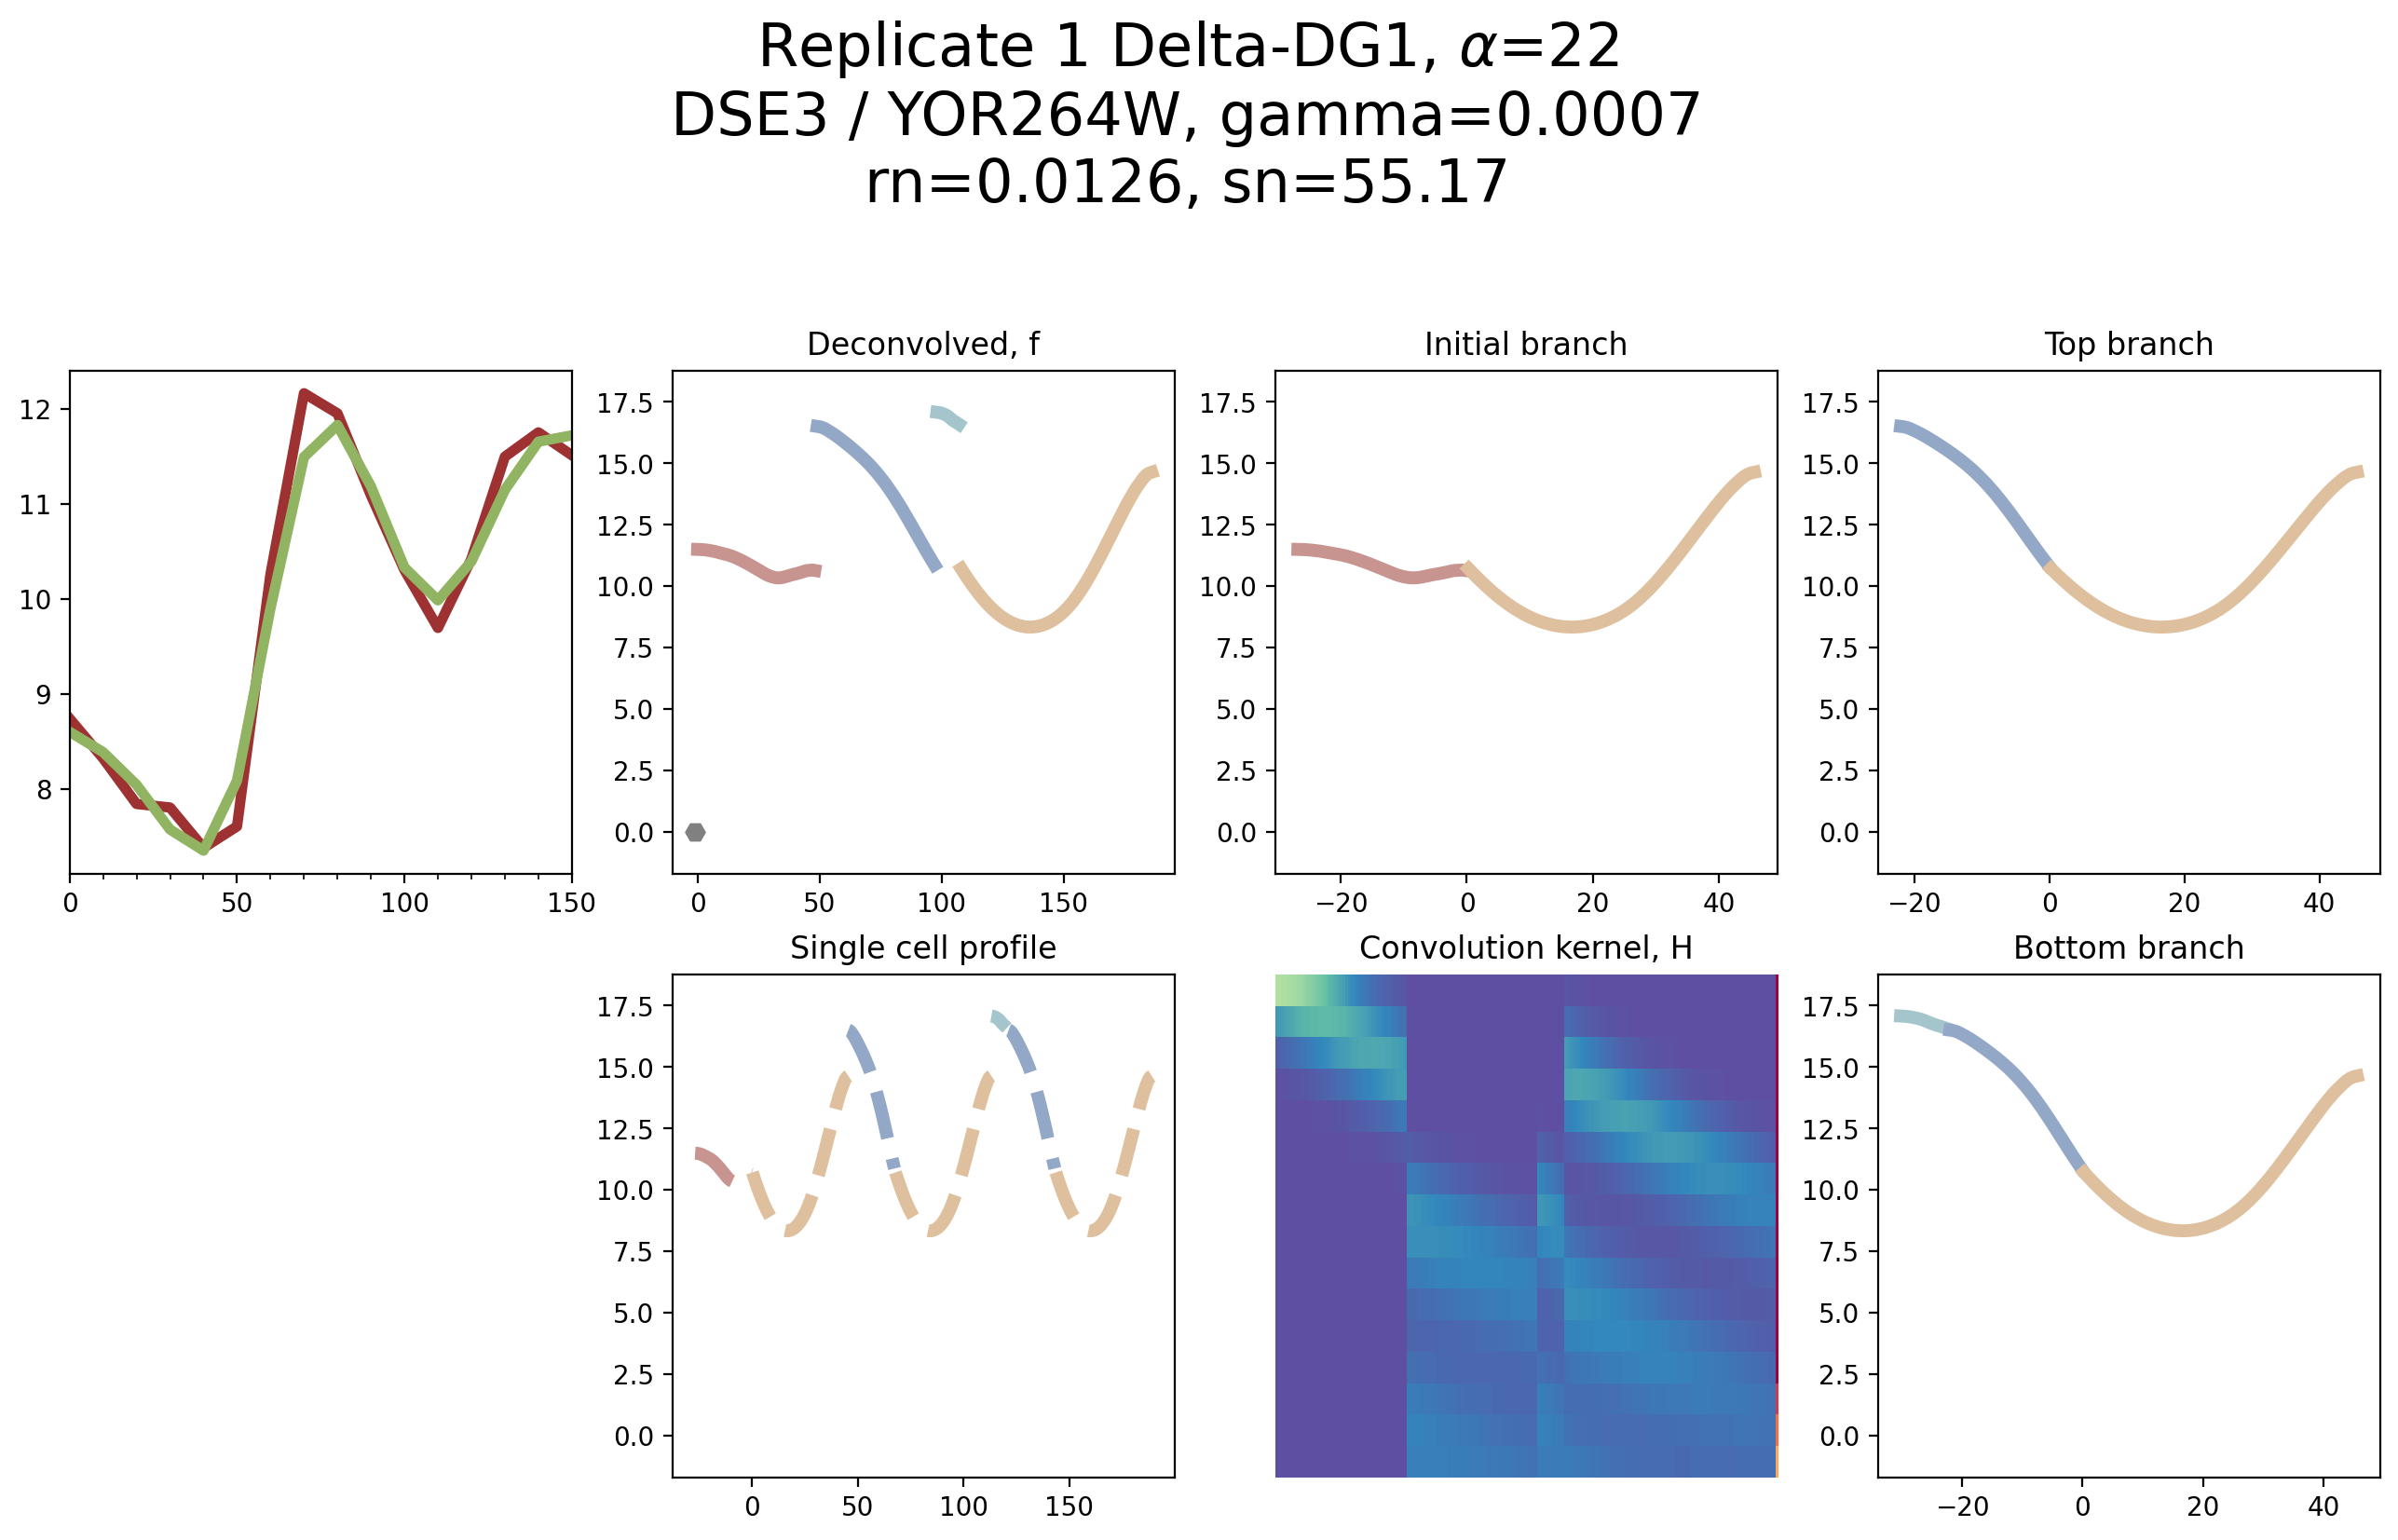

In [25]:
fig = model.plot_deconvolved_gene()

In [26]:
from src.chromatin_model import ChromatinModel

chrom_model = ChromatinModel(config1)
chrom_model.load_mnase_gene('CLB2')
# Deconvolve the chromatin.

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [27]:
chrom_model.create_deconvolution_bins()
chrom_model.setup_deconv_model()

In [28]:
chrom_model.setup_solver()

In [29]:
chrom_model.gamma = 0.008
chrom_model.deconvolve()

Deconvolving with gamma=0.008
0/340 - 00:00:00.135
100/340 - 00:00:11.773
200/340 - 00:00:23.986
300/340 - 00:00:35.808
Deconvolved in : 00:00:41.200
The fitting norm is 6.35, the smoothing norm is: 28.33


In [30]:
chrom_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 6.0038
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 6.0838, rate = 1.3
  ...   gm = 0.0050, rn = 6.2638, rate = 4.33, time = 00:01:48.557
  ...   gm = 0.0026, rn = 6.1985, rate = 3.24, time = 00:02:29.049
  ...   gm = 0.0013, rn = 6.1689, rate = 2.75, time = 00:03:08.969
  ...  search right, rn_goal = 8.4054, rate = 40.0
  ... rn range: [6.1689, 6.3908]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 6.1689, rate = 2.75, time = 00:04:29.832
  ...   gm = 0.0022, rn = 6.1921, rate = 3.14, time = 00:05:10.210
  ...   gm = 0.0031, rn = 6.2302, rate = 3.77, time = 00:05:50.700
  ...   gm = 0.0039, rn = 6.2404, rate = 3.94, time = 00:06:31.528
  ...   gm = 0.0048, rn = 6.2616, rate = 4.29, time = 00:07:11.467
  ...   gm = 0.0057, rn = 6.2934, rate = 4.82, time = 00:07:51.264
  ...   gm = 0.0065, 

In [66]:
#fig = chrom_model.create_deconvolution_plots_abbreviated_flipped()

In [35]:
from src.delta_config import load_delta_combined_gene_expression_config

combined_ge_config = load_delta_combined_gene_expression_config()

In [78]:
gene_name = 'AQY1'
combined_ge_model = Model(combined_ge_config, gene_name)

In [79]:
combined_ge_model.deconvolve_find_optimal_gamma()

In [80]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(config1, config2)
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YPR192W/AQY1...Loading chromosome reads: 16
Done.
Loading MNase reads for YPR192W/AQY1...Loading chromosome reads: 16
Done.


In [81]:
combined_model.deconvolve(gamma=0.006)
# combined_model.deconvolve_find_optimal_gamma()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.006
0/340 - 00:00:00.169
100/340 - 00:00:11.626
200/340 - 00:00:23.017
300/340 - 00:00:34.846
Deconvolved in : 00:00:40.684
The fitting norm is 14.79, the smoothing norm is: 22.13


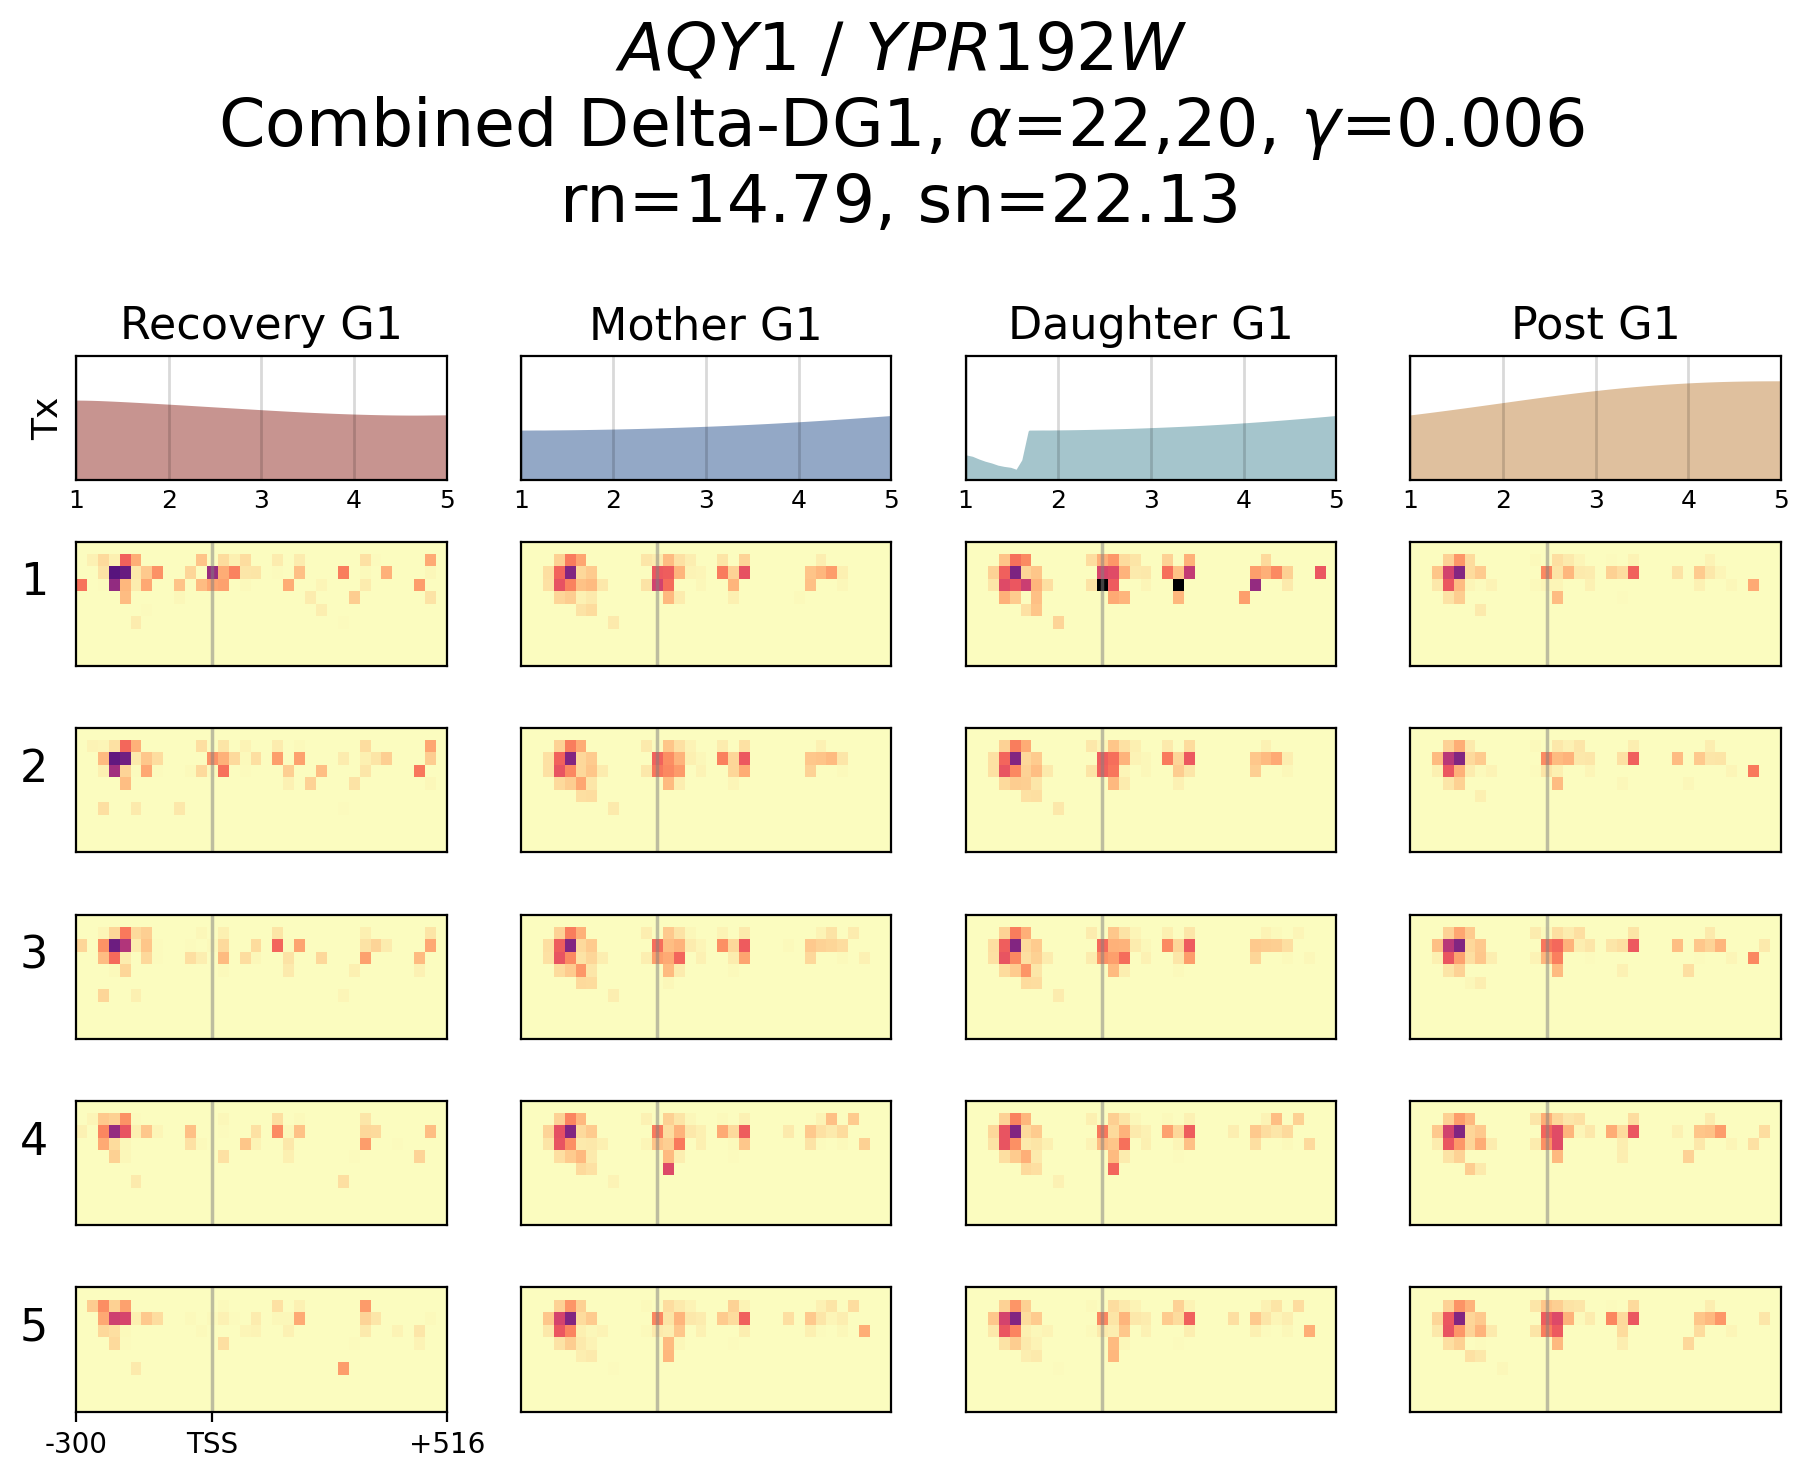

In [82]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(
    ge_model=combined_ge_model, vmax=50)

In [83]:
# Run the old deconvolution as well so we can compare the results for CLB2

In [84]:
from src.config import load_combined_yl_alpha_vst_gene_expression_config, \
    load_yl_rg1_vst_config

combined_old_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
old_config1 = load_yl_rg1_vst_config(1)
old_config2 = load_yl_rg1_vst_config(2)

In [85]:
combined_old_ge_model = Model(combined_old_ge_config, gene_name)
combined_old_ge_model.deconvolve_find_optimal_gamma()

In [86]:
combined_old_model = CombinedChromatinModel(old_config1, old_config2)
combined_old_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YPR192W/AQY1...Loading chromosome reads: 16
Done.
Loading MNase reads for YPR192W/AQY1...Loading chromosome reads: 16
Done.


In [87]:
combined_old_model.deconvolve(gamma=0.006)

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.006
0/340 - 00:00:00.146
100/340 - 00:00:11.632
200/340 - 00:00:23.521
300/340 - 00:00:35.280
Deconvolved in : 00:00:41.011
The fitting norm is 14.78, the smoothing norm is: 21.03


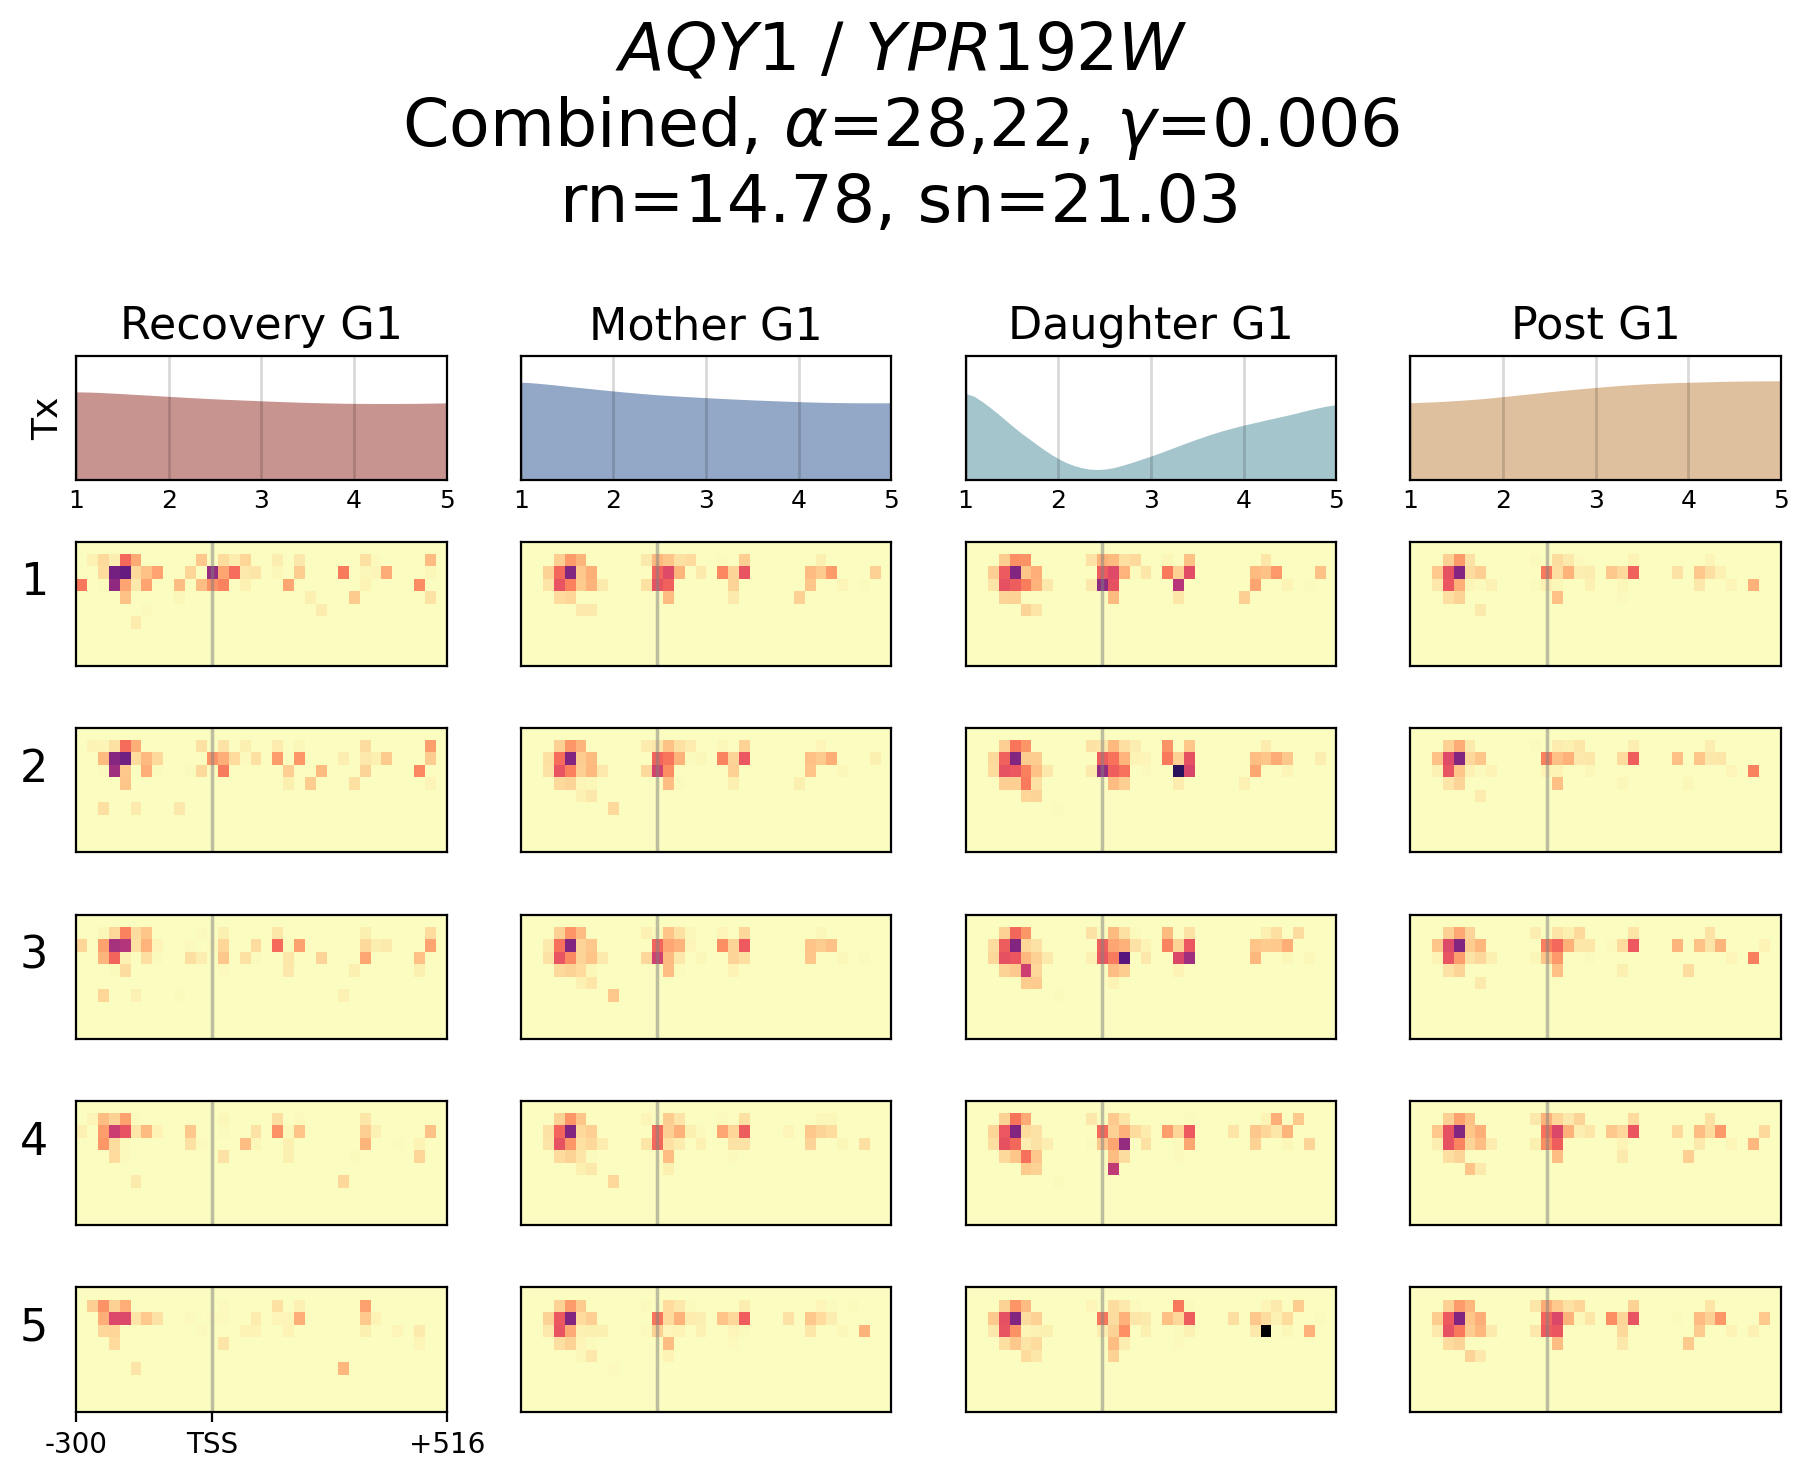

In [90]:
fig = combined_old_model.create_deconvolution_plots_abbreviated_flipped(
    ge_model=combined_old_ge_model, vmax=50)